# 1 - Imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0].parents[0]))

In [3]:
from src.utils import config, io
from src.preprocessing import preprocess_pipeline
from src.models import model_pipeline, evaluate

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/pypdf/_crypt_providers/_cryptography.py:32: CryptographyDeprecationWarning: ARC4 has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.ARC4 and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  from cryptography.hazmat.primitives.ciphers.algorithms import AES, ARC4


In [4]:
import mlflow
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns

from missingno import matrix as msno_matrix
from missingno import heatmap as msno_heatmap

sns.set_theme(style="whitegrid", context="talk")

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# 2 - Parameter Tuning XGBoost

In [6]:
def expanding_window_split(df, start_year, end_year, val_start_year):

    for val_year in range(val_start_year, end_year + 1):
        
        train_mask = (df['YEAR'] >= start_year) & (df['YEAR'] < val_year)
        val_mask = df['YEAR'] == val_year
        
        train_idx = df.index[train_mask]
        val_idx = df.index[val_mask]
        
        if len(val_idx) > 0:
            yield train_idx, val_idx


## 3.1 - Run Parameters Cross Validation

In [7]:
mlflow.set_tracking_uri(config.PROJECT_ROOT / 'models/mlruns')
mlflow.create_experiment('XGBoost Regressor Model Parameters')
mlflow.set_experiment('XGBoost Regressor Model Parameters')

<Experiment: artifact_location='file:///Users/hippolytegrandet/Desktop/Dev/country_risk_rating/models/mlruns/543985415730261480', creation_time=1771175352078, experiment_id='543985415730261480', last_update_time=1771175352078, lifecycle_stage='active', name='XGBoost Regressor Model Parameters', tags={}>

In [8]:
X = io.load_csv(config.PROCESSED_DATA_DIR / 'X.csv', index_col=0)
y = io.load_csv(config.PROCESSED_DATA_DIR / 'y.csv', index_col=0)

In [10]:
preprocessor_params = {
    'num_imputer': 'uni',
    'num_imputer_uni_strategy': 'most_frequent',
    'cat_imputer': 'uni',
    'cat_imputer_uni_strategy': 'most_frequent'
}
preprocessor = preprocess_pipeline.build_preprocessor(X, params=preprocessor_params)

In [12]:
model_params_grid = {
    'objective': ['reg:squarederror'],
    'min_child_weight': [1, 2, 3, 5],
    'gamma': [0.0, 0.1, 0.5, 1, 1.5, 2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'max_depth': [4, 6, 8, 10]
}

In [15]:
i = 0
for min_child_weight, gamma, subsample, colsample_bytree, max_depth in product( # solver, class_weight
    model_params_grid['min_child_weight'],
    model_params_grid['gamma'],
    model_params_grid['subsample'],
    model_params_grid['colsample_bytree'],
    model_params_grid['max_depth']
):

    i += 1
    if i%50 == 0:
        print('Progress', str(round(100*i/(np.prod([len(vs) for vs in model_params_grid.values()])), 1)), '%')

    model_params = {
        'objective': 'reg:squarederror',
        'min_child_weight': min_child_weight,
        'gamma': gamma,
        'subsample': subsample,
        'colsample_bytree': colsample_bytree,
        'max_depth': max_depth
    }

    cv_scores = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': [],
        'mae': [],
        'mse': []
    }

    with mlflow.start_run():
        correct = True
        for fold, (train_idx, val_idx) in enumerate(expanding_window_split(df=X, start_year=1999, end_year=2020, val_start_year=2015)):
            fold_prefix = 'fold_' + str(fold) + '_'
            
            X_train, y_train = X.loc[train_idx], y.loc[train_idx, 'OECD_RATING']
            X_val, y_val = X.loc[val_idx], y.loc[val_idx, 'OECD_RATING']
            
            model = model_pipeline.get_model_pipeline('xgboost_regressor', preprocessor, model_params)

            try:
                model.fit(X_train, y_train)
            except ValueError:
                print('Error with Params:', model_params)
                correct = False
                break

            val_fold_results = evaluate.evaluate_model_regressor(model, X_val, y_val, prefix=fold_prefix, verbose=False)

            cv_scores['accuracy'].append(val_fold_results[fold_prefix + 'accuracy'])
            cv_scores['precision'].append(val_fold_results[fold_prefix + 'precision'])
            cv_scores['recall'].append(val_fold_results[fold_prefix + 'recall'])
            cv_scores['f1'].append(val_fold_results[fold_prefix + 'f1'])
            cv_scores['mae'].append(val_fold_results[fold_prefix + 'mae'])
            cv_scores['mse'].append(val_fold_results[fold_prefix + 'mse'])

        mlflow.log_params(model_params)
        
        if fold == 0:
            cv_mean_scores = {'cv_mean_' + k: 0.0 for k, vs in cv_scores.items()}
        else:
            cv_mean_scores = {'cv_mean_' + k: np.mean(vs) for k, vs in cv_scores.items()}
            print(model_params)
            print(cv_mean_scores)
        mlflow.log_metrics(cv_mean_scores)

{'min_child_weight': 1, 'gamma': 0.0, 'subsample': 0.6, 'colsample_bytree': 0.6, 'max_depth': 4}
{'cv_mean_accuracy': np.float64(0.620704802354478), 'cv_mean_precision': np.float64(0.5784820197208568), 'cv_mean_recall': np.float64(0.6177724408688913), 'cv_mean_f1': np.float64(0.5722500248701851), 'cv_mean_mae': np.float64(0.6345509787400564), 'cv_mean_mse': np.float64(1.2162654896577199)}
{'min_child_weight': 1, 'gamma': 0.0, 'subsample': 0.6, 'colsample_bytree': 0.6, 'max_depth': 6}
{'cv_mean_accuracy': np.float64(0.6738511179892087), 'cv_mean_precision': np.float64(0.6210365900664832), 'cv_mean_recall': np.float64(0.6708717505820118), 'cv_mean_f1': np.float64(0.6230020818194836), 'cv_mean_mae': np.float64(0.5670479089021683), 'cv_mean_mse': np.float64(1.0730609893798828)}
{'min_child_weight': 1, 'gamma': 0.0, 'subsample': 0.6, 'colsample_bytree': 0.6, 'max_depth': 8}
{'cv_mean_accuracy': np.float64(0.6728055810423744), 'cv_mean_precision': np.float64(0.6252143102331454), 'cv_mean_rec

## 3.2 - Analysis

In [16]:
e = mlflow.set_experiment('XGBoost Regressor Model Parameters')
e.experiment_id

'543985415730261480'

In [17]:
client = mlflow.tracking.MlflowClient()
experiment_id = e.experiment_id
feat_select_runs = client.search_runs(experiment_id)
len(feat_select_runs)

869

In [18]:
rows = []
for run in feat_select_runs:
    run_dict = run.data.to_dictionary()

    row = {}
    for param, v in run_dict['params'].items():
        row[param] = v
    for metric, v in run_dict['metrics'].items():
        row[metric] = v

    rows.append(row)

In [19]:
df = pd.DataFrame(rows)
df = df.astype(float)
df = df.dropna(subset=['cv_mean_f1'])
df = df.drop_duplicates()
df

,gamma,max_depth,min_child_weight,colsample_bytree,subsample,cv_mean_precision,cv_mean_mae,cv_mean_f1,cv_mean_mse,cv_mean_accuracy,cv_mean_recall
0,2.0,10.0,5.0,1.0,1.0,0.594601,0.599343,0.593951,1.215093,0.653734,0.636930
1,2.0,8.0,5.0,1.0,1.0,0.597103,0.597165,0.594167,1.184681,0.652855,0.639453
2,2.0,6.0,5.0,1.0,1.0,0.578288,0.632528,0.570877,1.280887,0.628751,0.619051
3,2.0,4.0,5.0,1.0,1.0,0.542512,0.722294,0.518608,1.503820,0.562947,0.566493
4,2.0,10.0,5.0,0.8,1.0,0.599486,0.599691,0.594918,1.204357,0.642623,0.644293
...,...,...,...,...,...,...,...,...,...,...,...
862,0.0,6.0,1.0,0.6,0.6,0.621037,0.567048,0.623002,1.073061,0.673851,0.670872
863,0.0,4.0,1.0,0.6,0.6,0.578482,0.634551,0.572250,1.216265,0.620705,0.617772
865,0.0,8.0,1.0,0.6,0.6,0.625214,NaN,0.624590,NaN,0.672806,0.675365
866,0.0,6.0,1.0,0.6,0.6,0.621037,NaN,0.623002,NaN,0.673851,0.670872


In [20]:
df.sort_values(by=['cv_mean_f1'], ascending=False).head(20)

,gamma,max_depth,min_child_weight,colsample_bytree,subsample,cv_mean_precision,cv_mean_mae,cv_mean_f1,cv_mean_mse,cv_mean_accuracy,cv_mean_recall
836,0.0,10.0,1.0,0.6,1.0,0.682140,0.507669,0.692049,1.067080,0.730725,0.750115
404,0.0,10.0,3.0,0.6,1.0,0.677334,0.501726,0.690031,1.079303,0.738585,0.735418
620,0.0,10.0,2.0,0.6,1.0,0.678982,0.505006,0.689547,1.052569,0.734683,0.743627
401,0.0,8.0,3.0,0.8,1.0,0.676721,0.499722,0.686371,1.020059,0.735710,0.737796
837,0.0,8.0,1.0,0.6,1.0,0.675408,0.493743,0.684303,0.998345,0.730571,0.738808
832,0.0,10.0,1.0,0.8,1.0,0.673868,0.493779,0.683676,1.047976,0.724594,0.742194
189,0.0,8.0,5.0,0.6,1.0,0.671547,0.513171,0.682271,1.075278,0.726733,0.730384
621,0.0,8.0,2.0,0.6,1.0,0.673051,0.502886,0.681437,1.028851,0.731509,0.729810
828,0.0,10.0,1.0,1.0,1.0,0.670257,0.504273,0.680848,1.138095,0.733708,0.723808
792,0.1,10.0,1.0,1.0,1.0,0.669168,0.516769,0.680167,1.168015,0.731658,0.724437


In [46]:
model_params = {
    'gamma': 0.0,	
    'max_depth': 10.0,
    'min_child_weight': 1.0,
    'colsample_bytree': 0.8,
    'subsample': 1.0
}

### 3.2.1 Per Parameter Analysis

In [ ]:
model_params_grid = {
    'min_child_weight': [1, 5, 10],
    'gamma': [0.5, 1, 1.5, 2, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'max_depth': [4, 6, 8, 10]
}

#### Min Child Weight 

Text(0, 0.5, 'Mean F1 Score')

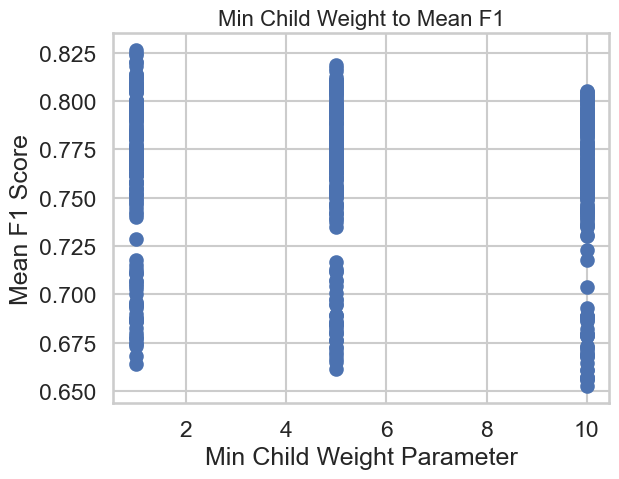

In [37]:
plt.scatter(df['min_child_weight'], df['cv_mean_f1'])
plt.title('Min Child Weight to Mean F1', fontsize=16)
plt.xlabel('Min Child Weight Parameter')
plt.ylabel('Mean F1 Score')

#### Gamma

Text(0, 0.5, 'Mean F1 Score')

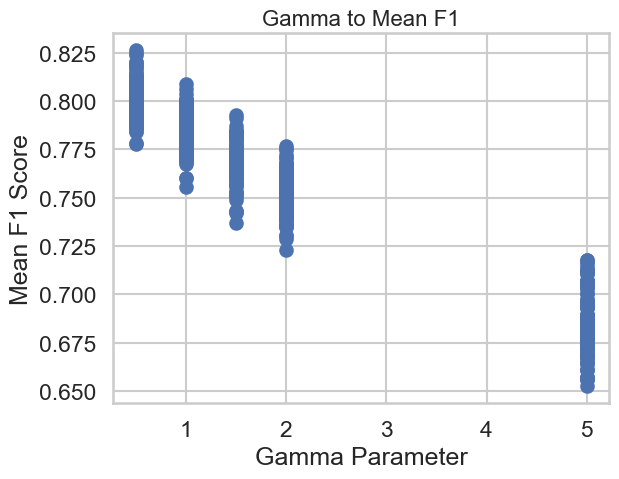

In [38]:
plt.scatter(df['gamma'], df['cv_mean_f1'])
plt.title('Gamma to Mean F1', fontsize=16)
plt.xlabel('Gamma Parameter')
plt.ylabel('Mean F1 Score')

#### Max Correlation Parameter

Text(0, 0.5, 'Mean F1 Score')

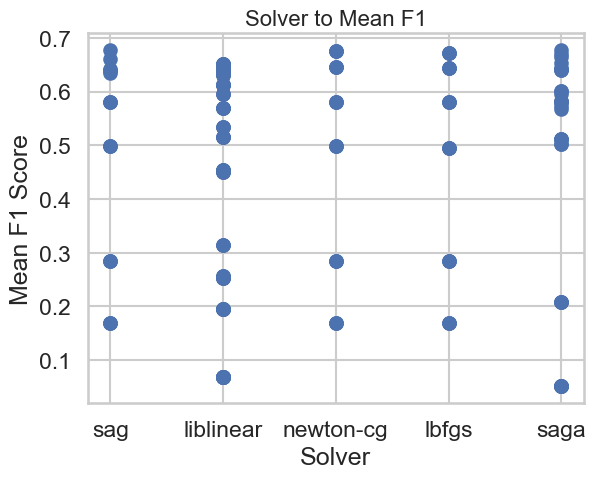

In [62]:
plt.scatter(df['solver'], df['cv_mean_f1'])
plt.title('Solver to Mean F1', fontsize=16)
plt.xlabel('Solver')
plt.ylabel('Mean F1 Score')

#### Max Iteration

Text(0, 0.5, 'Mean F1')

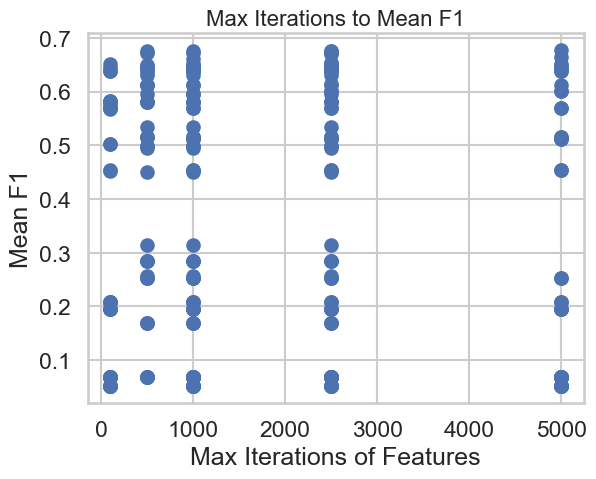

In [52]:
plt.scatter(df['max_iter'], df['cv_mean_f1'])
plt.title('Max Iterations to Mean F1', fontsize=16)
plt.xlabel('Max Iterations of Features')
plt.ylabel('Mean F1')

# 4 - Conclusion

In [ ]:
model_params = { 
    'penalty': 'l2',
    'C' : 10,
    'solver': 'newton-cg',
    'max_iter'  : 1000
}